Configuration

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import os
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from google.colab import drive
from tqdm import tqdm
import time
from sklearn.metrics import accuracy_score,precision_recall_fscore_support,classification_report
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

batch_size = 32
epochs = 50
lr = 1e-3

Device: cuda


Connect Drive to locate output

Load Dataset

In [ ]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

train_dataset = datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.FashionMNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

100%|██████████| 26.4M/26.4M [00:01<00:00, 13.2MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 209kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.89MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 12.9MB/s]


EDA

In [ ]:
print("Train:", len(train_dataset))
print("Test:", len(test_dataset))
print("Classes:", train_dataset.classes)

img, label = train_dataset[0]
print("Shape:", img.shape)
print("Number of labels:", label)

Train: 60000
Test: 10000
Classes: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
Shape: torch.Size([3, 224, 224])
Number of labels: 9


Counter({tensor(9): 1, tensor(0): 1, tensor(0): 1, tensor(3): 1, tensor(0): 1, tensor(2): 1, tensor(7): 1, tensor(2): 1, tensor(5): 1, tensor(5): 1, tensor(0): 1, tensor(9): 1, tensor(5): 1, tensor(5): 1, tensor(7): 1, tensor(9): 1, tensor(1): 1, tensor(0): 1, tensor(6): 1, tensor(4): 1, tensor(3): 1, tensor(1): 1, tensor(4): 1, tensor(8): 1, tensor(4): 1, tensor(3): 1, tensor(0): 1, tensor(2): 1, tensor(4): 1, tensor(4): 1, tensor(5): 1, tensor(3): 1, tensor(6): 1, tensor(6): 1, tensor(0): 1, tensor(8): 1, tensor(5): 1, tensor(2): 1, tensor(1): 1, tensor(6): 1, tensor(6): 1, tensor(7): 1, tensor(9): 1, tensor(5): 1, tensor(9): 1, tensor(2): 1, tensor(7): 1, tensor(3): 1, tensor(0): 1, tensor(3): 1, tensor(3): 1, tensor(3): 1, tensor(7): 1, tensor(2): 1, tensor(2): 1, tensor(6): 1, tensor(6): 1, tensor(8): 1, tensor(3): 1, tensor(3): 1, tensor(5): 1, tensor(0): 1, tensor(5): 1, tensor(5): 1, tensor(0): 1, tensor(2): 1, tensor(0): 1, tensor(0): 1, tensor(4): 1, tensor(1): 1, tensor(3): 

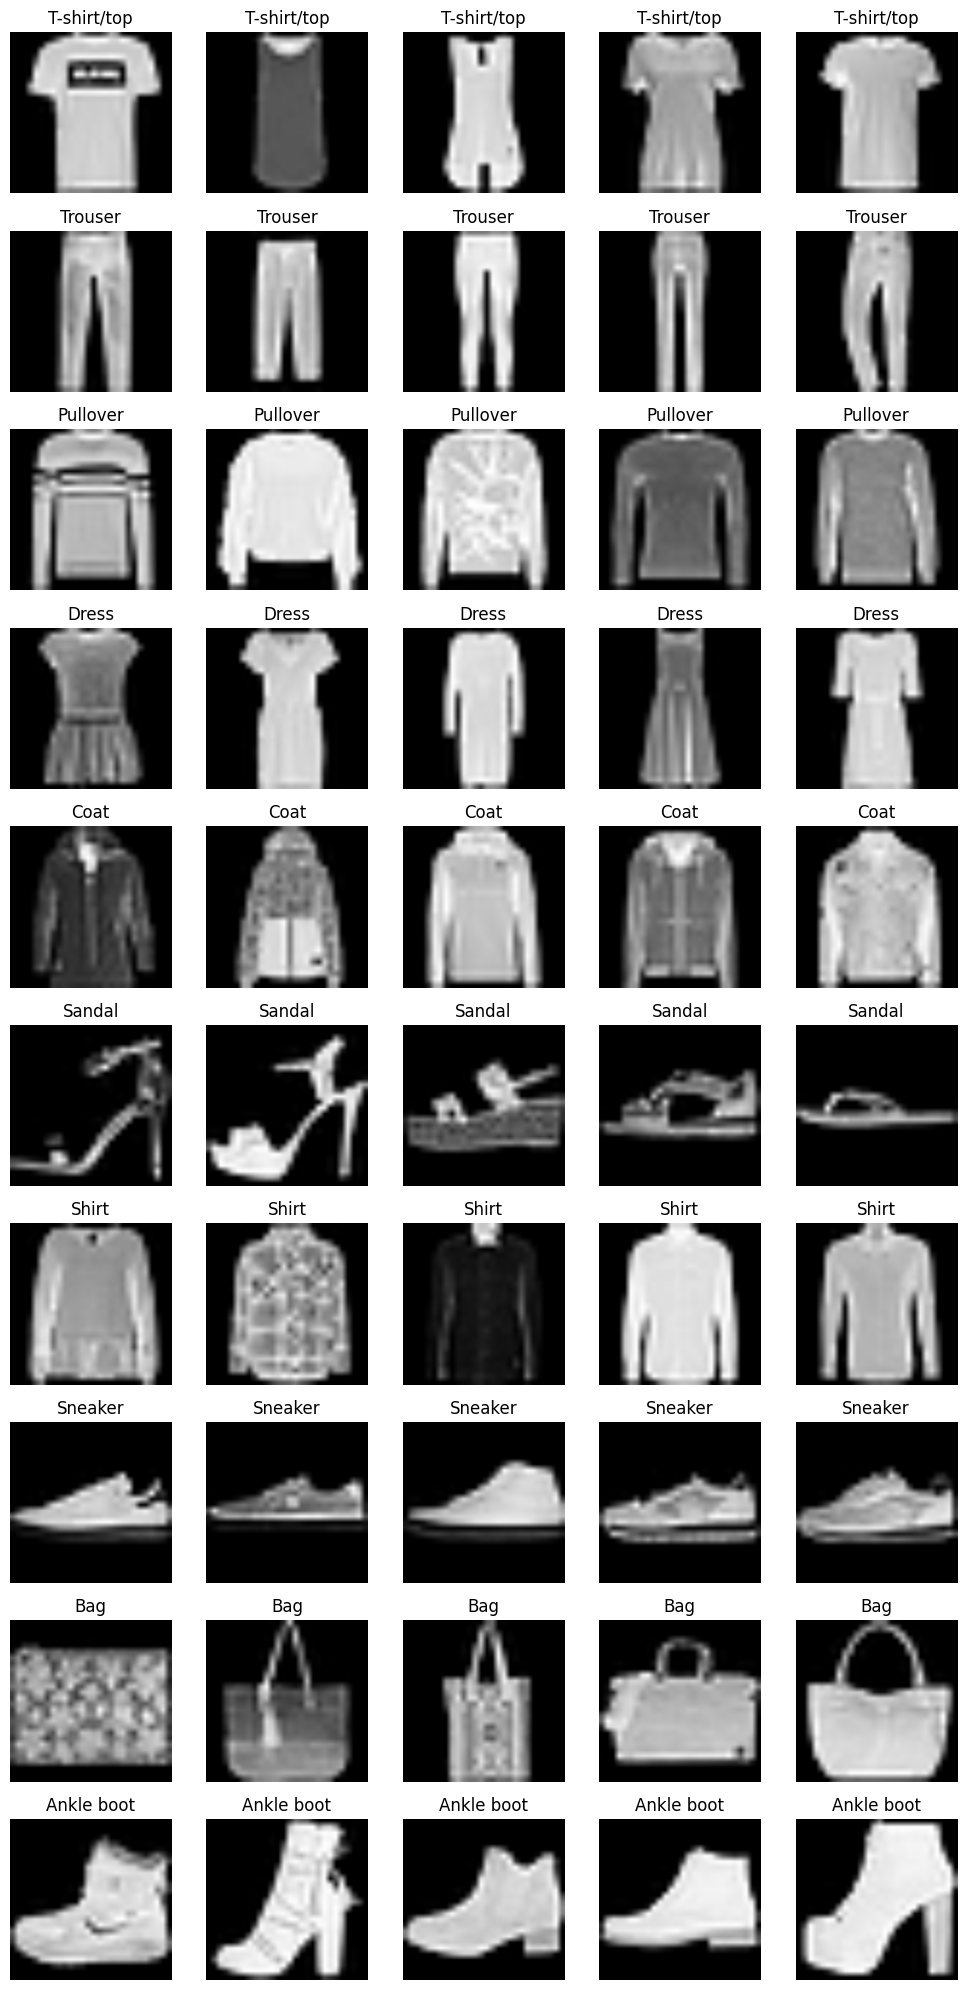

In [ ]:


class_names = train_dataset.classes
print(Counter(train_dataset.targets))


def show_samples_per_class(dataset, samples_per_class=5):
    num_classes = len(class_names)

    fig, axes = plt.subplots(num_classes, samples_per_class,
                             figsize=(samples_per_class * 2, num_classes * 2))

    if samples_per_class == 1:
        axes = axes.reshape(num_classes, 1)

    class_count = {i: 0 for i in range(num_classes)}

    for img, label in dataset:
        if class_count[label] < samples_per_class:
            row = label
            col = class_count[label]

            ax = axes[row, col]

            img = img.numpy().transpose(1, 2, 0)


            mean = np.array([0.5] * img.shape[2])
            std = np.array([0.5] * img.shape[2])
            img = img * std + mean
            img = np.clip(img, 0, 1)

            if img.shape[2] == 1:
                img = img.squeeze()
                ax.imshow(img, cmap='gray')
            else:
                ax.imshow(img)

            ax.set_title(class_names[label])
            ax.axis("off")

            class_count[label] += 1


        if all(v == samples_per_class for v in class_count.values()):
            break

    plt.tight_layout()
    plt.show()


show_samples_per_class(train_dataset, samples_per_class=5)

Class distribution:
Ankle boot: 6000
T-shirt/top: 6000
Dress: 6000
Pullover: 6000
Sneaker: 6000
Sandal: 6000
Trouser: 6000
Shirt: 6000
Coat: 6000
Bag: 6000


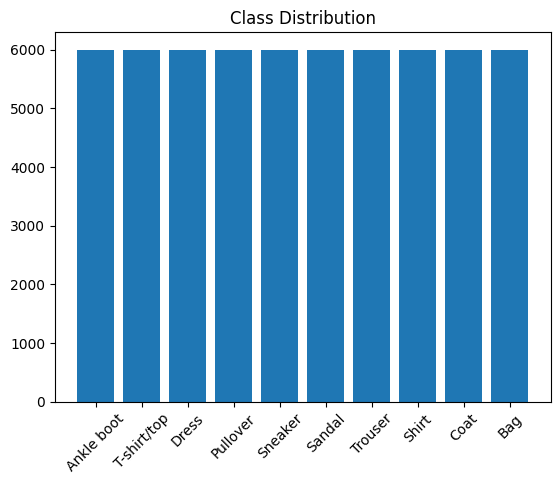

In [ ]:
import matplotlib.pyplot as plt

targets = train_dataset.targets.numpy()
count = Counter(targets)

print("Class distribution:")
for k, v in count.items():
    print(f"{class_names[k]}: {v}")

# plot
plt.bar([class_names[i] for i in count.keys()], count.values())
plt.xticks(rotation=45)
plt.title("Class Distribution")
plt.show()

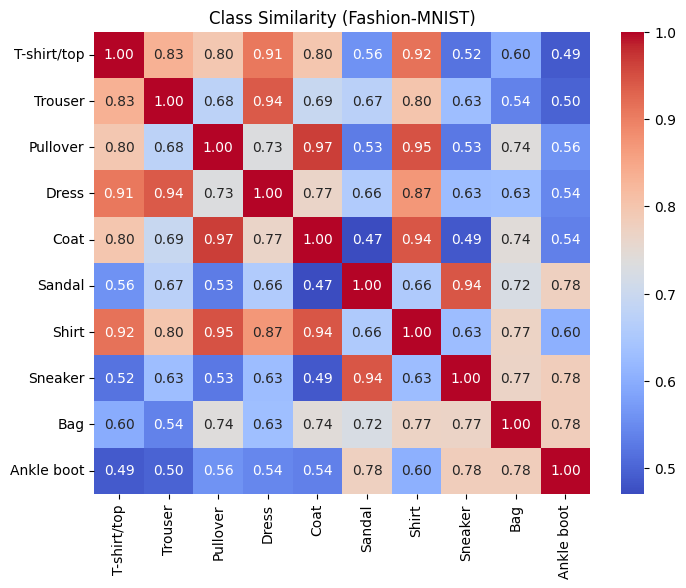


🔝 Most similar:
('Pullover', 'Coat', np.float32(0.9651041))
('Pullover', 'Shirt', np.float32(0.9478262))
('Sandal', 'Sneaker', np.float32(0.9432281))
('Coat', 'Shirt', np.float32(0.94250757))
('Trouser', 'Dress', np.float32(0.9396155))

⬇️ Least similar:
('T-shirt/top', 'Sneaker', np.float32(0.51837957))
('Trouser', 'Ankle boot', np.float32(0.49852276))
('T-shirt/top', 'Ankle boot', np.float32(0.48884606))
('Coat', 'Sneaker', np.float32(0.48659277))
('Coat', 'Sandal', np.float32(0.47065103))

Stats:
Mean: 0.7015652
Std: 0.14527814
Min: 0.47065103
Max: 0.9651041


In [ ]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# MEAN PER CLASS
num_classes = 10

class_sums = None
class_counts = torch.zeros(num_classes)

for images, labels in train_loader:
    if class_sums is None:
        class_sums = torch.zeros(num_classes, *images.shape[1:])

    for cls in range(num_classes):
        mask = (labels == cls)
        if mask.any():
            class_sums[cls] += images[mask].sum(dim=0)
            class_counts[cls] += mask.sum()

# mean
class_means = class_sums / class_counts[:, None, None, None]
# COSINE SIMILARITY
features = class_means.view(num_classes, -1)
features = F.normalize(features, dim=1)

sim_matrix = torch.matmul(features, features.T).cpu().numpy()

# HEATMAP
class_names = train_loader.dataset.classes

plt.figure(figsize=(8,6))
sns.heatmap(sim_matrix,
            xticklabels=class_names,
            yticklabels=class_names,
            annot=True,
            fmt=".2f",
            cmap="coolwarm")

plt.title("Class Similarity (Fashion-MNIST)")
plt.show()


#TOP SIMILAR / DISSIMILAR
sim = sim_matrix.copy()
np.fill_diagonal(sim, -1)

pairs = []
for i in range(num_classes):
    for j in range(i+1, num_classes):
        pairs.append((class_names[i], class_names[j], sim[i, j]))

pairs_sorted = sorted(pairs, key=lambda x: x[2], reverse=True)

print("\nMost similar:")
for p in pairs_sorted[:5]:
    print(p)

print("\nLeast similar:")
for p in pairs_sorted[-5:]:
    print(p)


# STATISTICS
upper = sim_matrix[np.triu_indices(num_classes, k=1)]

print("\nStats:")
print("Mean:", upper.mean())
print("Std:", upper.std())
print("Min:", upper.min())
print("Max:", upper.max())